# 05 — RL Agent: Contextual Bandit + Offline Q-Learning

**Goal:** Train an RL agent to recommend protocol adjustments that maximise `ProtocolValue`.

**Two RL approaches implemented:**

### 5A — Contextual Bandit (LinUCB)
- State: feature vector at time t
- Action: 3 discrete (Lower/Hold/Raise threshold)
- Reward: Δ ProtocolValue
- Policy: Upper Confidence Bound on linear reward model
- Best for: real-time deployment (lightweight, interpretable)

### 5B — Offline Q-Learning (tabular / neural)
- State: discretised feature vector
- Action: 3 discrete
- Reward: Δ ProtocolValue
- Trained entirely offline on historical data
- Best for: richer policy, deployable after pre-training

**Note on offline RL:** We cannot do online exploration (no live environment). We use batch RL: learn a policy from the logged data as if it were replay buffer.

In [1]:
import sys, json, warnings, pickle
sys.path.insert(0, '../src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

warnings.filterwarnings('ignore')

PROCESSED_DIR = Path('../data/processed')
OUTPUTS_DIR   = Path('../outputs')
FIGURES_DIR   = Path('../outputs/figures')

meta         = json.loads((PROCESSED_DIR/'feature_meta.json').read_text())
TARGET       = meta['target']
FEATURE_COLS = meta['feature_cols']
ACTION_MAP   = meta['action_map']
N_ACTIONS    = meta['n_actions']
SS_COL       = 'subsession'

plt.rcParams.update({
    'figure.facecolor':'#0d1117','axes.facecolor':'#161b22',
    'axes.labelcolor':'#e6edf3','xtick.color':'#8b949e',
    'ytick.color':'#8b949e','text.color':'#e6edf3',
    'grid.color':'#21262d','grid.linestyle':'--','font.family':'monospace'
})
print(f'Setup complete. Actions: {N_ACTIONS}, Features: {len(FEATURE_COLS)}')

Setup complete. Actions: 3, Features: 246


## 1. Load Data & Build Transitions

In [2]:
df = pd.read_parquet(PROCESSED_DIR/'features.parquet')
df_game = df[df[SS_COL]>0].copy()

# Build (state, action, reward, next_state) tuples
df_game['reward'] = df_game.groupby(SS_COL)[TARGET].diff(1)
df_game['reward'] = df_game['reward'].clip(
    df_game['reward'].quantile(0.02),
    df_game['reward'].quantile(0.98)
)

# Drop rows where any feature or reward is NaN
valid = df_game.dropna(subset=FEATURE_COLS + ['reward','action'])
print(f'Valid transitions: {len(valid):,}')

X      = valid[FEATURE_COLS].values.astype(np.float32)
A      = valid['action'].values.astype(int)
R      = valid['reward'].values.astype(np.float32)

print(f'State dim: {X.shape[1]}')
print(f'Action distribution: {dict(zip(*np.unique(A, return_counts=True)))}')
print(f'Reward: mean={R.mean():.4f}, std={R.std():.4f}')

Valid transitions: 2,667
State dim: 246
Action distribution: {np.int64(0): np.int64(309), np.int64(1): np.int64(502), np.int64(2): np.int64(1856)}
Reward: mean=0.0005, std=0.5930


## 2A. LinUCB Contextual Bandit

In [3]:
class LinUCB:
    """
    Linear Upper Confidence Bound bandit.
    One linear model per action. Exploration via confidence bound.
    Suitable for real-time deployment: O(d^2) per step.
    """
    def __init__(self, n_actions: int, n_features: int, alpha: float = 0.5):
        self.n_actions  = n_actions
        self.alpha      = alpha  # exploration coefficient
        self.A          = [np.eye(n_features) for _ in range(n_actions)]
        self.b          = [np.zeros(n_features) for _ in range(n_actions)]

    def predict(self, x: np.ndarray) -> int:
        """Choose action with highest UCB estimate."""
        ucbs = []
        for a in range(self.n_actions):
            A_inv = np.linalg.solve(self.A[a], np.eye(len(x)))
            theta = A_inv @ self.b[a]
            ucb   = theta @ x + self.alpha * np.sqrt(x @ A_inv @ x)
            ucbs.append(ucb)
        return int(np.argmax(ucbs))

    def update(self, x: np.ndarray, action: int, reward: float):
        """Update model for the chosen action."""
        self.A[action] += np.outer(x, x)
        self.b[action] += reward * x

    def get_theta(self) -> list:
        """Return estimated reward weights per action."""
        return [np.linalg.solve(self.A[a], np.eye(len(self.b[a]))) @ self.b[a]
                for a in range(self.n_actions)]


# ── Clean X: work in float64 throughout, cast to float32 only after clipping ─
# (large rolling-std features overflow float32 intermediate arithmetic)
X_f64 = valid[FEATURE_COLS].values.astype(np.float64)

inf_mask = ~np.isfinite(X_f64)
n_inf_total = int(inf_mask.sum())
if n_inf_total > 0:
    n_inf_per_col = inf_mask.sum(axis=0)
    top10_idx = np.argsort(n_inf_per_col)[::-1][:10]
    print(f'Found {n_inf_total} inf values across {int((n_inf_per_col > 0).sum())} columns')
    print('Top 10 columns by inf count:')
    for idx in top10_idx:
        if n_inf_per_col[idx] > 0:
            print(f'  {FEATURE_COLS[idx]}: {int(n_inf_per_col[idx])}')
else:
    print('No inf values found in X.')
X_f64[~np.isfinite(X_f64)] = np.nan
# Also mask values beyond float32 range — they are finite in float64 but
# overflow to inf when cast to float32 (seen in rolling-std features).
_F32_MAX = np.float64(np.finfo(np.float32).max)
X_f64[np.abs(X_f64) > _F32_MAX] = np.nan

# Median impute — stored in float64 for reuse on X_next
col_medians = np.nanmedian(X_f64, axis=0)
nan_mask = np.isnan(X_f64)
if nan_mask.any():
    rows, cols = np.where(nan_mask)
    X_f64[rows, cols] = col_medians[cols]

# Clip to ±10σ — compute stats in float64 to avoid overflow, store for X_next
col_mean = X_f64.mean(axis=0)
col_std  = X_f64.std(axis=0)
X_f64 = np.clip(X_f64, col_mean - 10 * col_std, col_mean + 10 * col_std)
X = X_f64.astype(np.float32)
print(f'X cleaned: shape={X.shape}, finite={np.isfinite(X).all()}')

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train LinUCB on all data (offline simulation)
bandit = LinUCB(n_actions=N_ACTIONS, n_features=X_scaled.shape[1], alpha=0.3)
bandit_actions = []
bandit_rewards = []

for i, (x, a_true, r) in enumerate(zip(X_scaled, A, R)):
    a_pred = bandit.predict(x)
    bandit_actions.append(a_pred)
    # Offline: only update if predicted action matches logged action
    # (inverse propensity / importance weighting approximation)
    if a_pred == a_true:
        bandit.update(x, a_pred, r)
        bandit_rewards.append(r)
    else:
        bandit_rewards.append(np.nan)

bandit_actions = np.array(bandit_actions)
bandit_rewards = np.array(bandit_rewards)

matched = ~np.isnan(bandit_rewards)
print(f'LinUCB training complete.')
print(f'  Matched actions (updated): {matched.sum()} ({matched.mean():.1%})')
print(f'  Mean reward on matched:    {np.nanmean(bandit_rewards):.4f}')
print(f'  Action distribution:       {dict(zip(*np.unique(bandit_actions, return_counts=True)))}')

No inf values found in X.
X cleaned: shape=(2667, 246), finite=True
LinUCB training complete.
  Matched actions (updated): 15 (0.6%)
  Mean reward on matched:    -0.0491
  Action distribution:       {np.int64(0): np.int64(1785), np.int64(1): np.int64(620), np.int64(2): np.int64(262)}


## 2B. Offline Q-Learning (FQI — Fitted Q-Iteration)

In [4]:
from sklearn.ensemble import GradientBoostingRegressor

# Fitted Q-Iteration:
# Q(s,a) ← fit regressor on (state, action) → reward + γ * max_a' Q(s',a')
# Iterate until convergence

GAMMA   = 0.95
N_ITER  = 10

# Build (s, a) features — one-hot encode action
A_onehot = np.eye(N_ACTIONS)[A]  # (n, 3)
SA       = np.hstack([X_scaled, A_onehot])  # (n, d+3)

# Next-state features (shift by 1 within subsession)
valid_shifted = valid.copy()
X_next_raw = valid.groupby(SS_COL)[FEATURE_COLS].shift(-1)
# ── Clean X_next — same float64 pipeline, reuse col_medians/col_mean/col_std ─
X_next_arr = X_next_raw.values.astype(np.float64)
X_next_arr[~np.isfinite(X_next_arr)] = np.nan
X_next_arr[np.abs(X_next_arr) > _F32_MAX] = np.nan
nan_mask_next = np.isnan(X_next_arr)
if nan_mask_next.any():
    rows, cols = np.where(nan_mask_next)
    X_next_arr[rows, cols] = col_medians[cols]
X_next_arr = np.clip(X_next_arr, col_mean - 10 * col_std, col_mean + 10 * col_std)
X_next = scaler.transform(X_next_arr.astype(np.float32))  # cast after clip

# Initialise Q-values to reward
Q_target = R.copy()
q_model  = None

for iteration in range(N_ITER):
    # Fit Q(s,a) → target
    q_model = GradientBoostingRegressor(
        n_estimators=100, learning_rate=0.1, max_depth=3,
        random_state=42, subsample=0.8
    )
    q_model.fit(SA, Q_target)

    # Update targets: r + γ * max_a' Q(s', a')
    next_q_vals = []
    for a_next in range(N_ACTIONS):
        A_next_oh = np.tile(np.eye(N_ACTIONS)[a_next], (len(X_next), 1))
        SA_next   = np.hstack([X_next, A_next_oh])
        next_q_vals.append(q_model.predict(SA_next))
    max_next_q = np.max(np.stack(next_q_vals, axis=1), axis=1)
    Q_target   = R + GAMMA * max_next_q

    if iteration % 3 == 0:
        print(f'  FQI iteration {iteration+1}/{N_ITER}: '
              f'Q-range=[{Q_target.min():.3f}, {Q_target.max():.3f}]')

print('FQI complete.')

# Derive greedy policy from Q-model
fqi_actions = []
for x in X_scaled:
    q_vals = []
    for a in range(N_ACTIONS):
        sa = np.hstack([x, np.eye(N_ACTIONS)[a]])
        q_vals.append(q_model.predict([sa])[0])
    fqi_actions.append(np.argmax(q_vals))
fqi_actions = np.array(fqi_actions)
print(f'FQI action distribution: {dict(zip(*np.unique(fqi_actions, return_counts=True)))}')

  FQI iteration 1/10: Q-range=[-2.013, 2.054]
  FQI iteration 4/10: Q-range=[-1.356, 1.688]
  FQI iteration 7/10: Q-range=[-1.377, 1.734]
  FQI iteration 10/10: Q-range=[-1.379, 1.848]
FQI complete.
FQI action distribution: {np.int64(0): np.int64(2661), np.int64(1): np.int64(6)}


## 3. RL Policy Evaluation

Policy evaluation (IPS estimate):
  Random policy:   mean reward = -0.0147  (n=883)
  LinUCB bandit:   mean reward = -0.0491  (n=15)
  FQI Q-learning:  mean reward = 0.0020    (n=309)
  Actual logged:   mean reward = 0.0005  (n=2667)


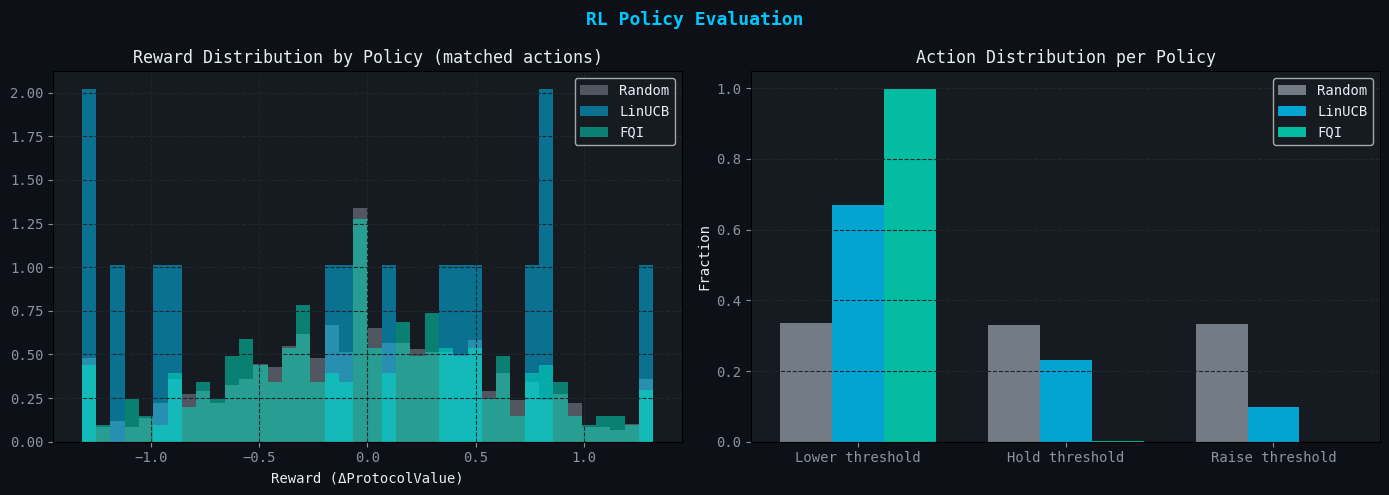

In [5]:
# Compare reward distributions: LinUCB vs FQI vs Random vs Actual
random_actions = np.random.default_rng(42).integers(0, N_ACTIONS, size=len(A))

def policy_reward(actions, true_actions, rewards):
    """Estimate reward using inverse propensity (matched actions only)."""
    matched = actions == true_actions
    if matched.sum() == 0: return np.nan, 0
    return rewards[matched].mean(), matched.sum()

r_random, n_random = policy_reward(random_actions, A, R)
r_bandit, n_bandit = policy_reward(bandit_actions, A, R)
r_fqi,    n_fqi    = policy_reward(fqi_actions,    A, R)
r_actual           = R.mean()

print('Policy evaluation (IPS estimate):')
print(f'  Random policy:   mean reward = {r_random:.4f}  (n={n_random})')
print(f'  LinUCB bandit:   mean reward = {r_bandit:.4f}  (n={n_bandit})')
print(f'  FQI Q-learning:  mean reward = {r_fqi:.4f}    (n={n_fqi})')
print(f'  Actual logged:   mean reward = {r_actual:.4f}  (n={len(R)})')

# Visualise reward distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('RL Policy Evaluation', color='#00c8ff', fontsize=13, fontweight='bold')

methods = [
    ('Random', random_actions, '#8b949e'),
    ('LinUCB', bandit_actions, '#00c8ff'),
    ('FQI',    fqi_actions,    '#00e5c3'),
]
for name, actions, color in methods:
    matched = actions == A
    if matched.sum() > 0:
        axes[0].hist(R[matched], bins=40, alpha=0.5, color=color, label=name, density=True)
axes[0].set_title('Reward Distribution by Policy (matched actions)')
axes[0].set_xlabel('Reward (ΔProtocolValue)')
axes[0].legend()
axes[0].grid(True)
axes[0].set_facecolor('#161b22')

# Action distributions
x_pos = np.arange(N_ACTIONS)
width = 0.25
for i, (name, actions, color) in enumerate(methods):
    counts = [np.sum(actions==a)/len(actions) for a in range(N_ACTIONS)]
    axes[1].bar(x_pos + i*width, counts, width, label=name, color=color, alpha=0.8)
axes[1].set_xticks(x_pos + width)
axes[1].set_xticklabels([ACTION_MAP[str(a)] for a in range(N_ACTIONS)])
axes[1].set_ylabel('Fraction')
axes[1].set_title('Action Distribution per Policy')
axes[1].legend()
axes[1].grid(True, axis='y')
axes[1].set_facecolor('#161b22')

plt.tight_layout()
plt.savefig('../outputs/figures/rl_policy_evaluation.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 4. Save RL Agents

In [6]:
with open(OUTPUTS_DIR/'linucb_agent.pkl','wb') as f:
    pickle.dump({'agent': bandit, 'scaler': scaler}, f)
with open(OUTPUTS_DIR/'fqi_agent.pkl','wb') as f:
    pickle.dump({'model': q_model, 'scaler': scaler, 'n_actions': N_ACTIONS}, f)

print('Saved: linucb_agent.pkl')
print('Saved: fqi_agent.pkl')

print('\n📌 RL Design Notes:')
print('  State:  z-normalised EEG + game state + lag/rolling features')
print('  Action: 3 discrete (Lower / Hold / Raise protocol threshold)')
print('  Reward: Δ ProtocolValue (clipped to [2%, 98%] range)')
print('  LinUCB: online-capable, lightweight, good for deployment')
print('  FQI:    richer policy, needs offline pre-training')

Saved: linucb_agent.pkl
Saved: fqi_agent.pkl

📌 RL Design Notes:
  State:  z-normalised EEG + game state + lag/rolling features
  Action: 3 discrete (Lower / Hold / Raise protocol threshold)
  Reward: Δ ProtocolValue (clipped to [2%, 98%] range)
  LinUCB: online-capable, lightweight, good for deployment
  FQI:    richer policy, needs offline pre-training
